# QEpy MD + Wavefunction Diagnostics (Minimal Example)

This notebook runs a short Andersen MD trajectory with QEpy and logs:
- potential/kinetic energy per atom
- KS eigenvalues at a selected k-point
- a two-band KS gap
- same-band wavefunction overlap magnitude/phase between consecutive MD steps

The goal is to show how to combine ASE MD control with QEpy electronic diagnostics.

In [ ]:
# --- optional pip installs (normally leave collapsed / do not run) ---
!pip install 'f90wrap<0.2.16' 'qepy'
!pip install ase
!pip install matplotlib

## User inputs

Set all run controls here:
- `N_STEPS`, `DT_FS`, `TEMPERATURE_K`, `ANDERSEN_PROB`
- `BANDS` and `KPT` for electronic diagnostics
- `INPUTFILE` and output location

For a quick demo, keep `N_STEPS` small.

In [69]:
from pathlib import Path

# --- run parameters ---
# Keep all user-facing knobs in one place.
WORKDIR = Path("./")
OUTDIR = WORKDIR / "."
N_STEPS = 5
BANDS = (3, 4)  # band indices used for eigenvalue/overlap tracking
KPT = 0         # k-point index
TEMPERATURE_K = 300.0
DT_FS = 1.0
ANDERSEN_PROB = 0.02
USE_MPI = False
SEED = 2020

## Imports and runtime dependencies

This notebook uses:
- `ASE` for MD and trajectory handling
- `QEpyCalculator` for forces/energies/electronic data
- `NumPy` for array math
- `matplotlib` for plotting

In [70]:
import csv
import os
from pathlib import Path

import numpy as np
from ase import Atoms, units
from ase.io.trajectory import Trajectory
from ase.md.andersen import Andersen
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from qepy.calculator import QEpyCalculator

In [ ]:
# Download H & O pseudopotential once into the notebook folder.
#!wget "http://www.quantum-simulation.org/potentials/sg15_oncv/upf/H_ONCV_PBE-1.2.upf" #For Linux
!curl "http://www.quantum-simulation.org/potentials/sg15_oncv/upf/H_ONCV_PBE-1.2.upf" > H_ONCV_PBE-1.2.upf #For Mac
#!wget "http://www.quantum-simulation.org/potentials/sg15_oncv/upf/O_ONCV_PBE-1.2.upf" #For Linux
!curl "http://www.quantum-simulation.org/potentials/sg15_oncv/upf/O_ONCV_PBE-1.2.upf" > O_ONCV_PBE-1.2.upf #For Mac

## Build atoms, calculator, and MD engine

This block:
1. enters the working directory
2. creates the QEpy calculator from the QE input file
3. attaches calculator to ASE atoms
4. initializes velocities at target temperature
5. creates Andersen dynamics
6. allocates buffers for time-series data

In [ ]:
# QE options copied from h2o_in_aimd.in
qe_options = {
    "&control": {
        "calculation": "'scf'",
        "restart_mode": "'from_scratch'",
        "disk_io": "'none'",
        "pseudo_dir": "'./'",
    },
    "&system": {
        "ibrav": 0,
        "nat": 3,
        "nbnd": 10,
        "ntyp": 2,
        "ecutwfc": 40,
        "occupations": "'smearing'",
        "degauss": 0.001,
        "smearing": "'gaussian'",
        "nosym": True,
    },
    "&electrons": {
        "electron_maxstep": 100,
        "conv_thr": 1e-6,
        "mixing_beta": 0.7,
        "diago_thr_init": 1.0e-4,
        "diago_david_ndim": 2,
    },
    "atomic_species": [
        "O  15.999   O_ONCV_PBE-1.2.upf",
        "H  1.008    H_ONCV_PBE-1.2.upf",
    ],
    "k_points gamma": True,
    "cell_parameters angstrom": [
        "8.00000000000000 0.00000000000000 0.00000000000000",
        "0.00000000000000 8.00000000000000 0.00000000000000",
        "0.00000000000000 0.00000000000000 8.00000000000000",
    ],
    "atomic_positions angstrom": [
        "O 3.0000000000 3.0000000000 3.2859286667",
        "H 3.0000000000 3.7632390000 2.6896196667",
        "H 3.0000000000 2.2367610000 2.6896196667",
    ],
}

qe_options

In [71]:
os.chdir(WORKDIR)
OUTDIR.mkdir(parents=True, exist_ok=True)

# Deterministic thermostat randomness for reproducible demo runs.
np.random.seed(SEED)
comm = None
log_path = OUTDIR / "tmp.out"

# Build ASE Atoms from qe_options (cell + symbols + positions).
cell = np.array(
    [[float(x) for x in row.split()] for row in qe_options["cell_parameters angstrom"]],
    dtype=float,
)
position_lines = qe_options["atomic_positions angstrom"]
symbols = [line.split()[0] for line in position_lines]
positions = np.array([[float(x) for x in line.split()[1:4]] for line in position_lines], dtype=float)
atoms = Atoms(symbols=symbols, positions=positions, cell=cell, pbc=True)

# Build QEpy calculator directly from qe_options.
calc = QEpyCalculator(comm=comm, qe_options=qe_options, logfile=str(log_path))
atoms.calc = calc

# Initialize velocities and MD integrator/thermostat.
MaxwellBoltzmannDistribution(atoms, temperature_K=TEMPERATURE_K, force_temp=True)
dyn = Andersen(atoms, DT_FS * units.fs, temperature_K=TEMPERATURE_K, andersen_prob=ANDERSEN_PROB,)

# Normalize requested bands once (sorted + unique).
bands = tuple(sorted(set(BANDS)))
kpt = KPT

# Buffers for time series and wavefunction-derived observables.
steps_md = []
epot_pa = []
ekin_pa = []
temp_k = []
wf_rows = []
psi_prev = {b: None for b in bands}
md_step = {"i": 0}

## Overlap metric definition

`overlap(prev, cur)` computes same-band overlap between consecutive MD steps:
- magnitude: electronic-state continuity indicator
- phase: gauge/phase evolution indicator

The overlap is normalized by wavefunction norms.

In [72]:
def overlap(prev, cur):
    """Return overlap magnitude and phase between two same-band wavefunctions."""
    if prev is None:
        return np.nan, np.nan
    ov_n = np.sum(np.conjugate(prev) * cur)
    n_prev = np.sum(np.conjugate(prev) * prev).real
    n_cur = np.sum(np.conjugate(cur) * cur).real
    wv_nrm = np.sqrt(n_prev * n_cur)
    ov = ov_n / wv_nrm
    return float(np.abs(ov)), float(np.angle(ov))

## Per-step data collection callback

`on_step()` is called every MD step and records:
- per-atom energies
- selected eigenvalues and optional two-band gap
- same-band overlap metrics using current vs previous wavefunctions

In [73]:
def on_step():
    # Called by ASE every MD step.
    a = dyn.atoms
    s = md_step["i"]; md_step["i"] += 1
    n = len(a)

    # Store basic thermodynamic observables per atom.
    steps_md.append(s)
    epot_pa.append(float(a.get_potential_energy() / n))
    ekin_pa.append(float(a.get_kinetic_energy() / n))

    # Only root rank writes wavefunction/eigenvalue diagnostics.
    if not getattr(a.calc, "is_root", True):
        return

    # KS eigenvalues at the selected k-point.
    eps = np.asarray(calc.get_eigenvalues(kpt=kpt), dtype=float)
    row = {"step": s, **{f"eval_b{b}": float(eps[b]) for b in bands}}

    # Add simple two-band gap if exactly two bands are tracked.
    if len(bands) == 2:
        b0, b1 = sorted(bands)
        row[f"gap_b{b1}_b{b0}"] = float(eps[b1] - eps[b0])

    # Wavefunctions are returned in the same order as `bands`.
    psi_list = calc.get_wave_function(kpt=kpt, band=bands)
    for b, psi_b in zip(bands, psi_list):
        psi_b = np.asarray(psi_b, dtype=np.complex128).ravel()
        mag, ph = overlap(psi_prev[b], psi_b)
        row[f"ovl_abs_b{b}"] = mag
        row[f"ovl_phase_b{b}"] = ph
        psi_prev[b] = psi_b

    wf_rows.append(row)

## Run dynamics and write outputs

This block runs MD and writes:
- `md.traj` trajectory
- `md_observables.csv` (step, potential/kinetic energy per atom)
- `wf_overlap.csv` (eigenvalues, gap, overlap magnitude/phase)

In [74]:

# Run MD and record atomic trajectory + custom observables each step.
traj_path = OUTDIR / "md.traj"
traj = Trajectory(str(traj_path), "w", atoms)
dyn.attach(traj.write, interval=1)
dyn.attach(on_step, interval=1)
dyn.run(N_STEPS)
traj.close()

# Save per-step energies.
csv_md = OUTDIR / "md_observables.csv"
with open(csv_md, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["step", "epot_Ha_per_atom", "ekin_Ha_per_atom"])
    for i, s in enumerate(steps_md):
        w.writerow([s, epot_pa[i], ekin_pa[i]])

# Save eigenvalue/gap/overlap diagnostics.
csv_wf = OUTDIR / "wf_overlap.csv"
if wf_rows:
    keys = sorted(wf_rows[0].keys())
    keys.remove("step")
    fieldnames = ["step"] + keys
    with open(csv_wf, "w", newline="") as f:
        dw = csv.DictWriter(f, fieldnames=fieldnames)
        dw.writeheader()
        dw.writerows(wf_rows)

print("Wrote:", csv_md)
print("Wrote:", csv_wf)
print("Wrote:", traj_path)
print("Wrote:", log_path)

Wrote: md_observables.csv
Wrote: wf_overlap.csv
Wrote: md.traj
Wrote: tmp.out


## Plot diagnostics

Panels show:
- potential energy per atom
- kinetic energy per atom
- KS gap for selected band pair
- same-band overlap magnitude for tracked bands

Interpretation tip: overlap values near 1 indicate smooth electronic-state evolution between steps.

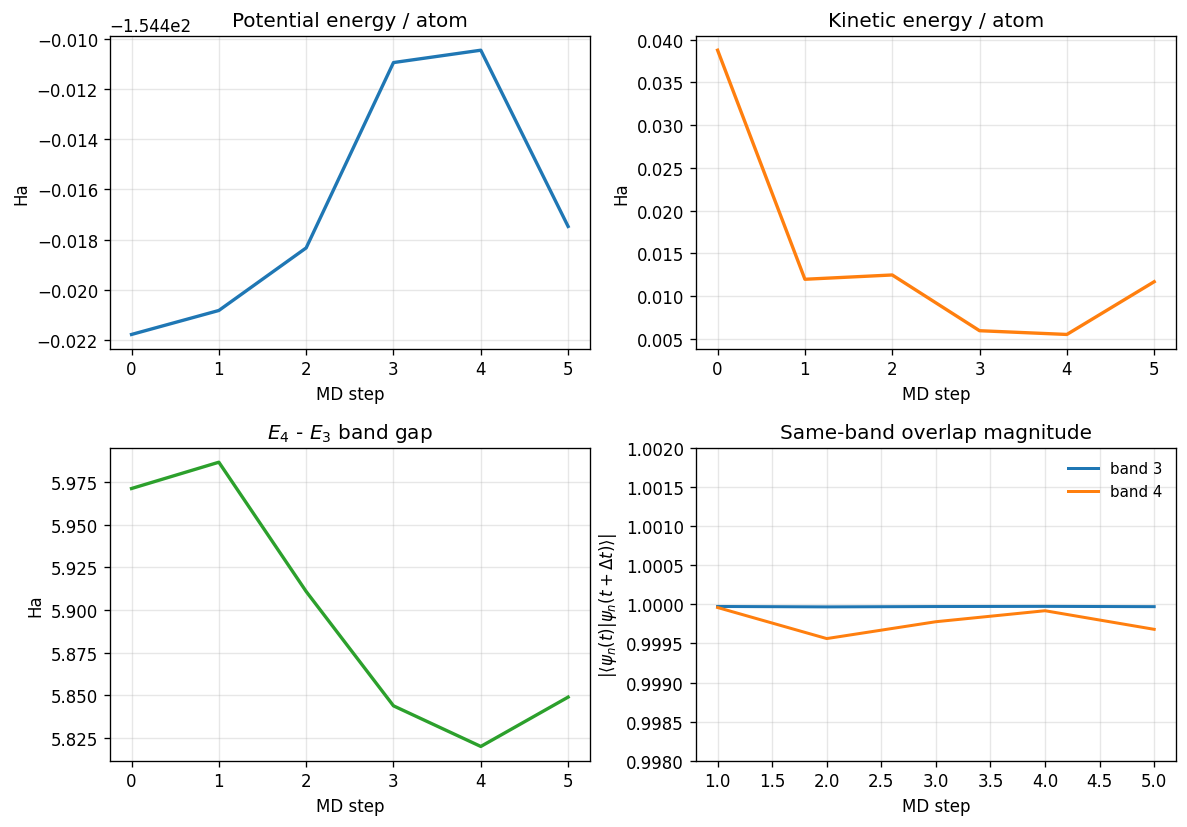

In [75]:
import numpy as np
import matplotlib.pyplot as plt

# Convert collected lists to arrays for plotting.
sw = np.asarray(steps_md, dtype=float)
ep = np.asarray(epot_pa, dtype=float)
ek = np.asarray(ekin_pa, dtype=float)

swf = np.asarray([r["step"] for r in wf_rows], dtype=float)
gap_key = f"gap_b{max(bands)}_b{min(bands)}"
gap = np.asarray([float(r.get(gap_key, np.nan)) for r in wf_rows], dtype=float)

fig, axs = plt.subplots(2, 2, figsize=(10, 7), dpi=120)

# Potential and kinetic energy trends.
axs[0, 0].plot(sw, ep, lw=2, color="tab:blue")
axs[0, 0].set_title("Potential energy / atom")
axs[0, 0].set_xlabel("MD step")
axs[0, 0].set_ylabel("Ha")
axs[0, 0].grid(alpha=0.3)

axs[0, 1].plot(sw, ek, lw=2, color="tab:orange")
axs[0, 1].set_title("Kinetic energy / atom")
axs[0, 1].set_xlabel("MD step")
axs[0, 1].set_ylabel("Ha")
axs[0, 1].grid(alpha=0.3)

# KS gap for the selected two-band pair.
axs[1, 0].plot(swf, gap, lw=2, color="tab:green")
axs[1, 0].set_title(f"$E_4$ - $E_3$ band gap")
axs[1, 0].set_xlabel("MD step")
axs[1, 0].set_ylabel("Ha")
axs[1, 0].grid(alpha=0.3)

# Same-band overlap magnitude for each tracked band.
for b in bands:
    y = np.asarray([float(r.get(f"ovl_abs_b{b}", np.nan)) for r in wf_rows], dtype=float)
    axs[1, 1].plot(swf, y, lw=1.8, label=f"band {b}")
axs[1, 1].set_title("Same-band overlap magnitude")
axs[1, 1].set_xlabel("MD step")
axs[1, 1].set_ylabel(r"$|\langle \psi_n(t)|\psi_n(t+\Delta t)\rangle|$")
axs[1, 1].set_ylim(0.998, 1.002)
axs[1, 1].grid(alpha=0.3)
axs[1, 1].legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()